In this notebook, we compare multiple loss functions to find train good models for the jaguar reidentification. We use DINOv3 as backbone. After embedding we use a newly trained models using ArcFaceLoss. We compare the identity-based mAP for the validation set, the number of parameters and the training time. The notebooks compares the following loss functions:
1. ArcFace
2. CosFace
3. SphereFace
4. Cross-Entropy
5. Focal Loss

## 1. Setup and Configuration

In [1]:
EXPERIMENT_NAME = "loss"
RANDOM_SEED = 51

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.visualization import visualize_embeddings_mds

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 51 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [108]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    
    # CosFace
    "cosface_margin": 0.35,
    "cosface_scale": 30.0,
    
    # SphereFace
    "sphereface_margin": 4,
    "sphereface_scale": 64.0,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    
    # SubCenterArcFace
    "subcenter_arcface_margin": 0.5,
    "subcenter_arcface_scale": 64.0,
    "subcenter_arcface_num_subcenters": 3,
    
    # BatchHardTriplet
    "batch_hard_triplet_margin": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  arcface_margin: 0.5
  arcface_scale: 64.0
  cosface_margin: 0.35
  cosface_scale: 30.0
  sphereface_margin: 4
  sphereface_scale: 64.0
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  subcenter_arcface_margin: 0.5
  subcenter_arcface_scale: 64.0
  subcenter_arcface_num_subcenters: 3
  batch_hard_triplet_margin: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 51


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


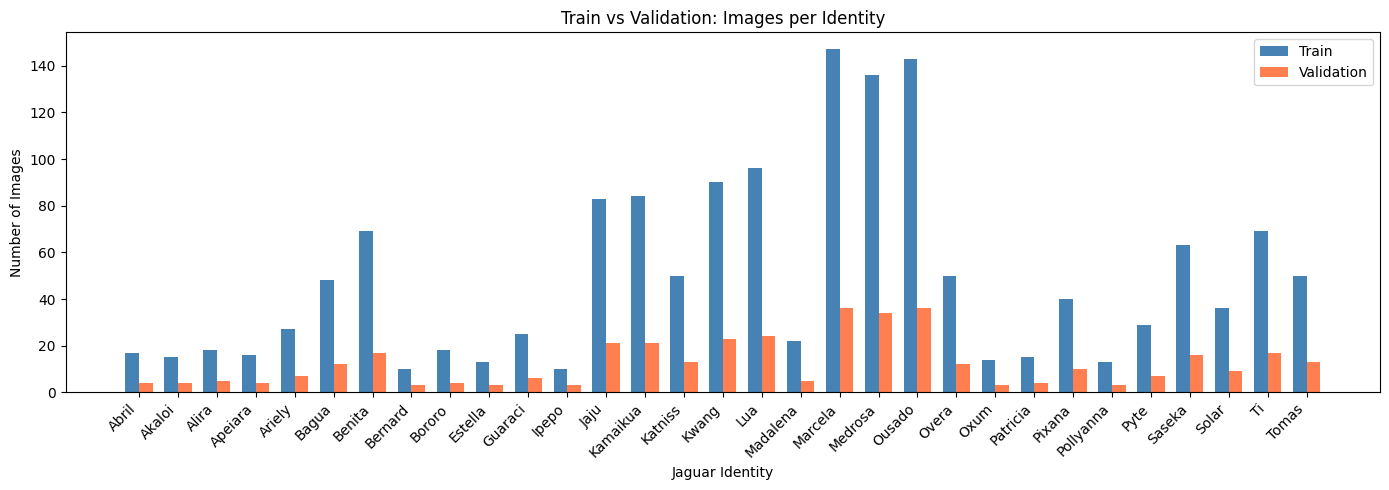


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [9]:
@torch.no_grad()
def extract_embeddings(model, data_loader, desc="Extracting embeddings"):
    """Extract embeddings for a batch of images."""
    model.eval()
    embeddings = []

    for batch in tqdm(data_loader, desc=desc):
        batch = batch.to(device)
        with torch.no_grad():
            emb = model(batch)
        embeddings.append(emb.cpu().numpy())

    return np.concatenate(embeddings, axis=0)

print("Embedding extraction function defined")

Embedding extraction function defined


In [10]:
# Extract baseline embeddings for training data

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])

    if len(cached_filenames) != len(expected_filenames):
        return None

    if set(cached_filenames) != set(expected_filenames):
        return None

    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

def get_embeddings(model, cache_path, data_loader):
    embeddings = None
    if cache_path.exists():
        embeddings = _load_cached_embeddings(cache_path, filenames)
        if embeddings is not None:
            print(f"Loaded cached embeddings from {cache_path}")
            print(f"Embeddings shape: {embeddings.shape}")
            
    if embeddings is None:
        print(f"Extracting embeddings for {len(data_loader)} images...")
        embeddings = extract_embeddings(
            model,
            data_loader
        )
        np.savez_compressed(
            cache_path,
            embeddings=embeddings,
            filenames=np.array(filenames, dtype=object),
        )
        print(f"Saved embeddings cache to {cache_path}")
        print(f"Embeddings shape: {embeddings.shape}")
        
    return embeddings


In [11]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [12]:
class EmbeddingProjection(nn.Module):
    """
    Projects embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
                
    def reset(self):
        self._init_weights()
    
    def forward(self, x):
        return self.network(x)

print("EmbeddingProjection defined")

EmbeddingProjection defined


In [13]:
class ImageDataset(Dataset):
    """PyTorch Dataset for images."""
    
    def __init__(self, filepaths, preprocess):
        self.filepaths = filepaths
        self.preprocess = preprocess

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        return self.preprocess(image)

In [14]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
        
        assert len(self.embeddings) == len(self.labels), "Embeddings and labels must have the same length"
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]

In [15]:
def compute_validation_map(model, val_loader):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    val_embeddings = []
    val_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            embeddings = model(images)
            embeddings = F.normalize(embeddings, p=2, dim=1)
            val_embeddings.append(embeddings.cpu().numpy())
            val_labels.append(labels.cpu().numpy())

    val_embeddings = np.concatenate(val_embeddings)
    val_labels = np.concatenate(val_labels)

    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(val_embeddings)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity

    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [16]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        finetuned_embeddings = model(embeddings)
        loss = criterion(finetuned_embeddings, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        total += labels.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    return avg_loss


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)

            finetuned_embeddings = model(embeddings)
            loss = criterion(finetuned_embeddings, labels)

            total_loss += loss.item()
            total += labels.size(0)
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    return avg_loss


print("Training and validation functions defined")

Training and validation functions defined


In [17]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, device, name):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_map': [], 'lr': []
    }

    best_val_map = 0.0
    patience_counter = 0
    best_epoch = 0

    print(f"Starting training for {config['num_epochs']} epochs...")
    print("=" * 70)

    for epoch in range(config['num_epochs']):
        print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
        
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss = validate_epoch(model, val_loader, criterion, device)
        
        # Compute validation mAP
        val_map = compute_validation_map(
            model, 
            val_loader,
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_map)
        history['lr'].append(current_lr)
        
        # Log to W&B
        wandb.log({
            'model': name,
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_map': val_map,
            'learning_rate': current_lr,
        })
        
        # Print summary
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")
        
        # Checkpoint best model
        if val_map > best_val_map:
            best_val_map = val_map
            best_epoch = epoch + 1
            patience_counter = 0

            checkpoint_path = CHECKPOINT_PATH / f"model_best_{name}.pth"
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_map': val_map,
                'config': config,
                'label_encoder_classes': label_encoder.classes_.tolist(),
                'num_classes': num_classes,
                'name': name
            }, checkpoint_path)
            
            print(f"  [New best model saved]")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
        
        # Early stopping
        if patience_counter >= config['patience']:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "=" * 70)
    print(f"Training complete!")
    print(f"Best epoch: {best_epoch}, Val mAP: {best_val_map:.4f}")

    return history, best_val_map, best_epoch

print("Train function defined")

Train function defined


In [18]:
def plot_history(history, best_epoch):
    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    epochs_range = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
    axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # mAP
    axes[1].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
    axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP')
    axes[1].set_title('Validation mAP (Identity-Balanced)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    
    return fig


In [19]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...


Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [20]:
image_dataset = ImageDataset(image_paths, dino_preprocess)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [21]:
baseline_cache_path = EMBEDDINGS_PATH / "dino_baseline_embeddings.npz"

baseline_embeddings = get_embeddings(
    dino,
    baseline_cache_path,
    image_loader
)

Extracting embeddings for 60 images...


Extracting embeddings: 100%|██████████| 60/60 [06:16<00:00,  6.27s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/embeddings/dino_baseline_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


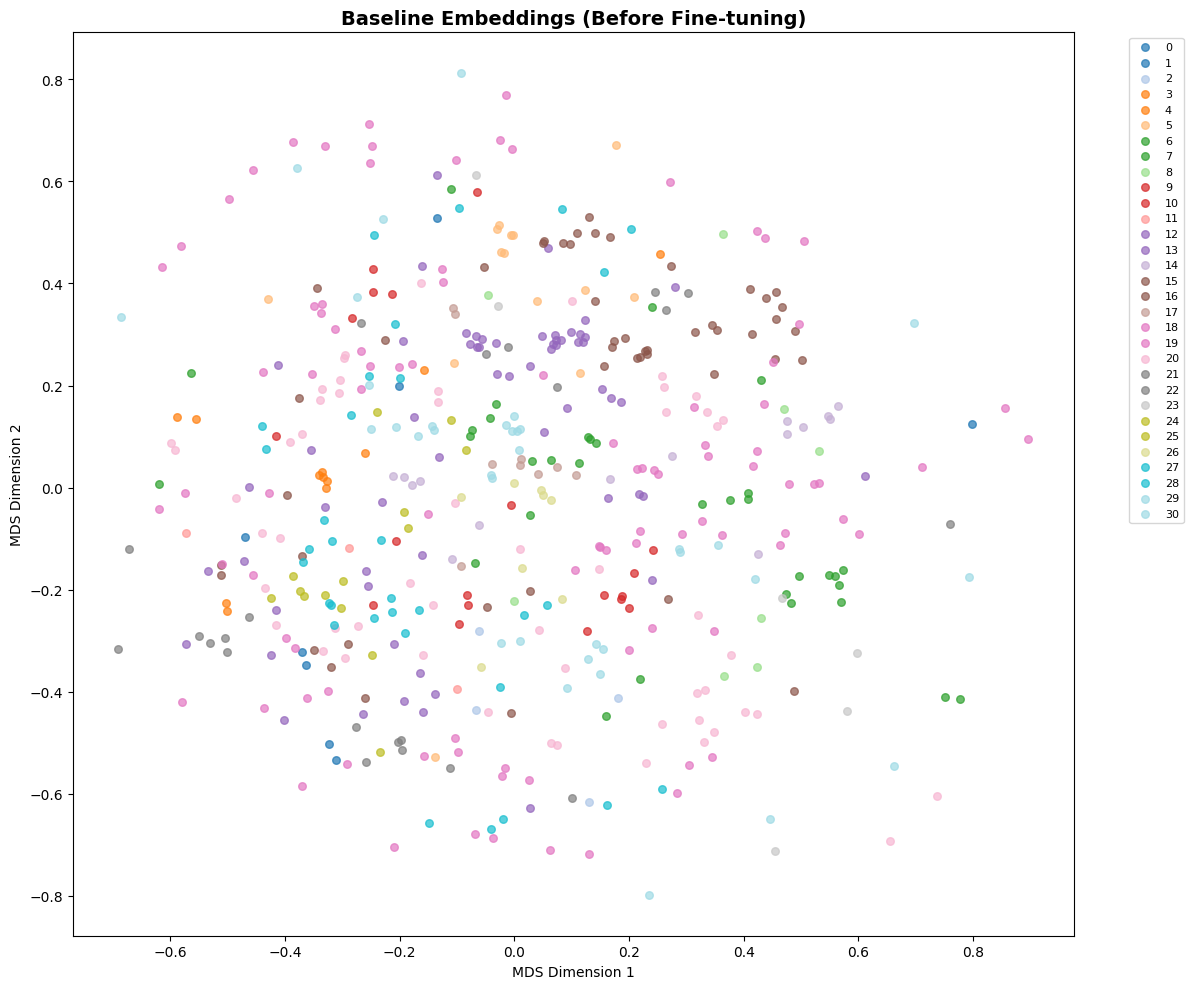

In [22]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [23]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=2,
    shuffle=False
)

In [26]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model_num_params = sum(p.numel() for p in model.parameters())

print(f"Embedding Projection Model defined:")
print(f"  Total parameters: {model_num_params:,}")

Embedding Projection Model defined:
  Total parameters: 526,592


In [27]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/model_initial_weights.pth


In [28]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch"]
]

## ArcFace

In [29]:

class ArcFaceLoss(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    
    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        # Compute cos(theta + m) using angle addition formula
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Apply threshold to handle theta + m >= pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encode labels
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale logits
        logits = output * self.scale
        loss = F.cross_entropy(logits, labels)

        return loss

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

ArcFace Loss:
  Embedding dim: 256
  Num classes: 31
  ArcFace margin: 0.5
  ArcFace scale: 64.0


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [33]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="arcface"
)

wandb.log({
    "final_val_mAP_arcface": best_map,
    "best_epoch_arcface": best_epoch,
    "total_epochs_arcface": len(history['train_loss']),
})

table.append([
    "ArcFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 37.0747
  Val Loss:   33.0929
  Val mAP:    0.3414 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.5414
  Val Loss:   28.4102
  Val mAP:    0.3627 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.4571
  Val Loss:   24.9665
  Val mAP:    0.3828 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.2438
  Val Loss:   2.9225
  Val mAP:    0.8526 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 115/200


  Train Loss: 0.2369
  Val Loss:   2.9013
  Val mAP:    0.8543 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 116/200


  Train Loss: 0.2202
  Val Loss:   2.9073
  Val mAP:    0.8592 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 117/200


  Train Loss: 0.1845
  Val Loss:   2.8945
  Val mAP:    0.8571 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 118/200


  Train Loss: 0.1656
  Val Loss:   2.8745
  Val mAP:    0.8567 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 118 epochs

Training complete!
Best epoch: 108, Val mAP: 0.8616


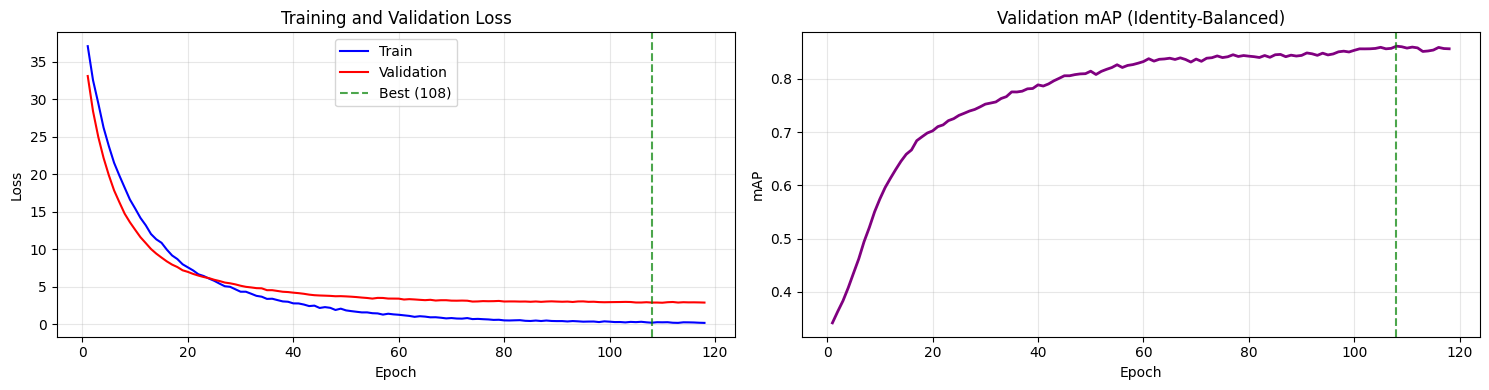

In [34]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_arcface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_arcface": wandb.Image(fig)})

In [35]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_arcface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 2.8766
  Val mAP: 0.8616


In [36]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


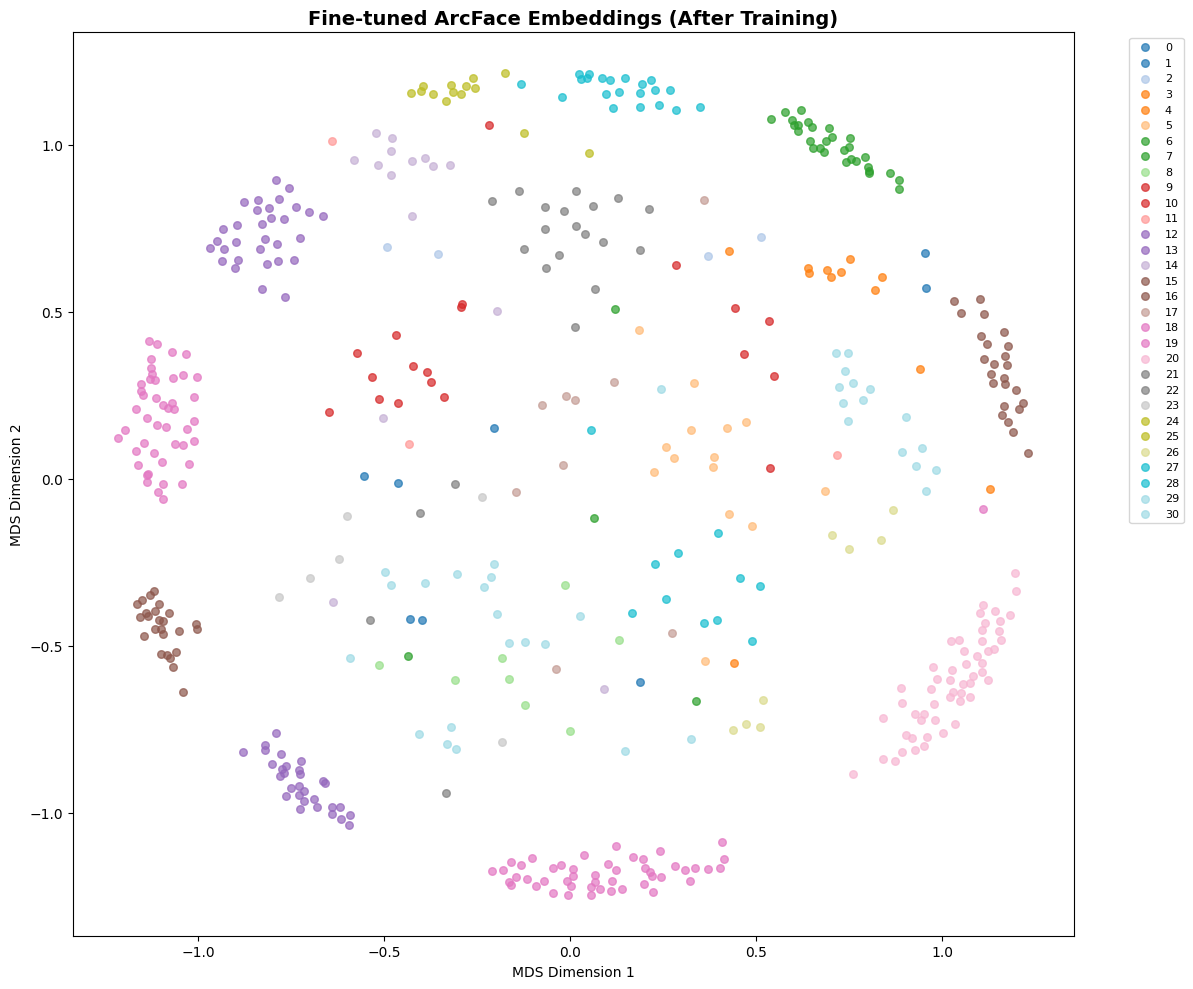

In [37]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "arcface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_arcface": wandb.Image(fig_finetuned)})

In [38]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## CosFace

In [39]:

class CosFaceLoss(nn.Module):
    """
    TODO: Implement
    CosFace (Additive Angular Margin Loss) layer.

    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # One-hot encode labels
        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()
        cosine_m = cosine - one_hot * self.margin
        
        # Scale logits
        logits = cosine_m * self.scale
        loss = F.cross_entropy(logits, labels)

        return loss

print(f"CosFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  CosFace margin: {config['cosface_margin']}")
print(f"  CosFace scale: {config['cosface_scale']}")

CosFace Loss:
  Embedding dim: 256
  Num classes: 31
  CosFace margin: 0.35
  CosFace scale: 30.0


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CosFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CosFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [43]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="cosface"
)

wandb.log({
    "final_val_mAP_cosface": best_map,
    "best_epoch_cosface": best_epoch,
    "total_epochs_cosface": len(history['train_loss']),
})

table.append([
    "CosFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 37.0003
  Val Loss:   32.9371
  Val mAP:    0.3430 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.4142
  Val Loss:   28.3746
  Val mAP:    0.3586 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.9215
  Val Loss:   24.9113
  Val mAP:    0.3835 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 26.1790
  Val Loss:   22.1486
  Val mAP:    0.4108 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.2513
  Val Loss:   2.9768
  Val mAP:    0.8478 | LR: 2.50e-05
  No improvement. Patience: 6/10

Epoch 102/200


  Train Loss: 0.2361
  Val Loss:   2.9716
  Val mAP:    0.8440 | LR: 2.50e-05
  No improvement. Patience: 7/10

Epoch 103/200


  Train Loss: 0.2647
  Val Loss:   2.9512
  Val mAP:    0.8470 | LR: 2.50e-05
  No improvement. Patience: 8/10

Epoch 104/200


  Train Loss: 0.3131
  Val Loss:   2.9880
  Val mAP:    0.8417 | LR: 2.50e-05
  No improvement. Patience: 9/10

Epoch 105/200


  Train Loss: 0.2079
  Val Loss:   2.9872
  Val mAP:    0.8463 | LR: 2.50e-05
  No improvement. Patience: 10/10

Early stopping triggered after 105 epochs

Training complete!
Best epoch: 95, Val mAP: 0.8495


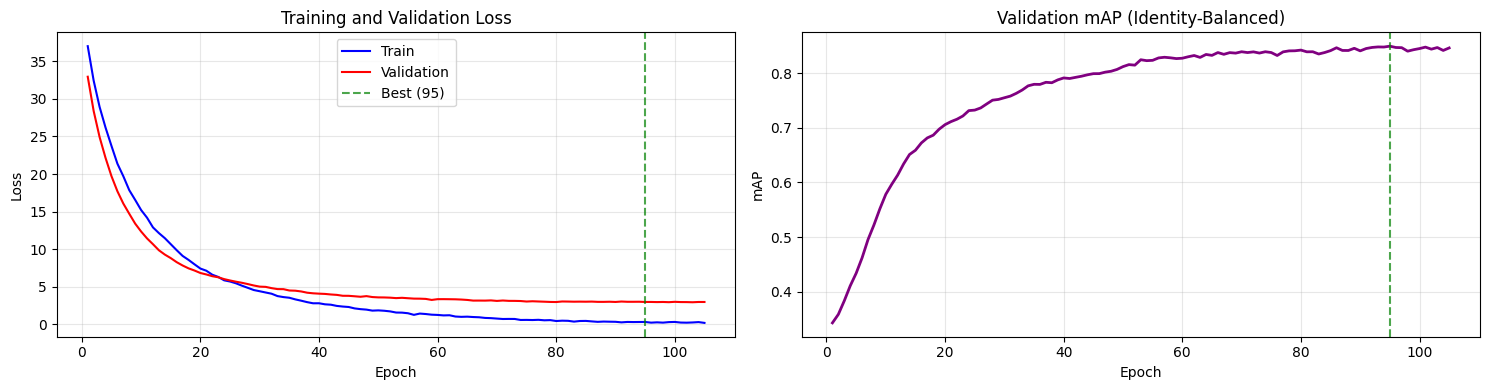

In [44]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_cosface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_cosface": wandb.Image(fig)})

In [45]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_cosface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 2.9892
  Val mAP: 0.8495


In [46]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


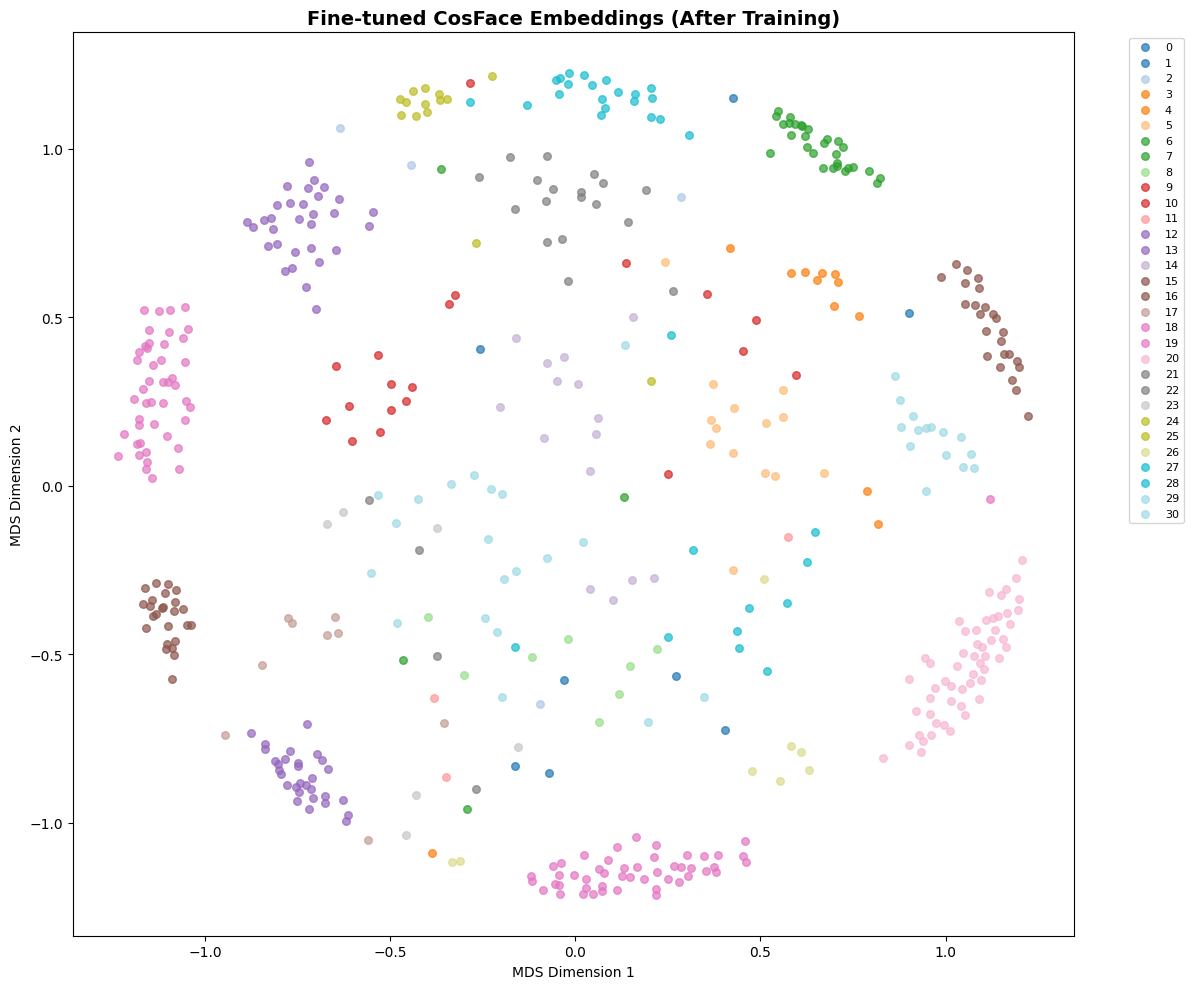

In [47]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned CosFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "cosface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_cosface": wandb.Image(fig_finetuned)})

In [48]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## SphereFace

In [109]:
class SphereFaceLoss(nn.Module):
    """
    SphereFace / A-Softmax Loss

    Paper:
    SphereFace: Deep Hypersphere Embedding for Face Recognition
    https://arxiv.org/abs/1704.08063

    L = -log( exp(s * cos(m * theta_y)) /
              (exp(s * cos(m * theta_y)) + sum_j exp(s * cos(theta_j))) )
    """

    def __init__(self, embedding_dim, num_classes, margin=4, scale=64.0):
        super().__init__()

        assert isinstance(margin, int) and margin >= 1, \
            "SphereFace margin m must be an integer >= 1"

        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.m = margin
        self.s = scale

        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # Normalize features and weights
        x = F.normalize(embeddings, dim=1)
        W = F.normalize(self.weight, dim=1)

        # cos(theta)
        cosine = F.linear(x, W).clamp(-1.0, 1.0)

        # cos(m * theta) using Chebyshev polynomials
        cos_m_theta = self._cos_m_theta(cosine)

        # theta = arccos(cos(theta)) (only used to compute k, detached)
        theta = torch.acos(cosine.detach())

        # k = floor(m * theta / pi)
        k = (self.m * theta / math.pi).floor()

        # phi(theta) = (-1)^k * cos(mθ) - 2k
        phi = ((-1.0) ** k) * cos_m_theta - 2 * k

        # One-hot labels
        one_hot = F.one_hot(labels, self.num_classes).float()

        # Replace target logits
        logits = one_hot * phi + (1.0 - one_hot) * cosine
        logits *= self.s

        loss = F.cross_entropy(logits, labels)
        return loss

    def _cos_m_theta(self, cos_theta):
        """
        Compute cos(m * theta) via Chebyshev polynomials.
        """
        if self.m == 1:
            return cos_theta
        elif self.m == 2:
            return 2 * cos_theta**2 - 1
        elif self.m == 3:
            return 4 * cos_theta**3 - 3 * cos_theta
        elif self.m == 4:
            return 8 * cos_theta**4 - 8 * cos_theta**2 + 1
        elif self.m == 5:
            return 16 * cos_theta**5 - 20 * cos_theta**3 + 5 * cos_theta
        else:
            # Recursive Chebyshev (rarely used in practice)
            T0 = torch.ones_like(cos_theta)
            T1 = cos_theta
            for _ in range(2, self.m + 1):
                T2 = 2 * cos_theta * T1 - T0
                T0, T1 = T1, T2
            return T1

print(f"SphereFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SphereFace margin: {config['sphereface_margin']}")
print(f"  SphereFace scale: {config['sphereface_scale']}")

SphereFace Loss:
  Embedding dim: 256
  Num classes: 31
  SphereFace margin: 4
  SphereFace scale: 64.0


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SphereFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["sphereface_margin"],
    scale=config["sphereface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: SphereFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: SphereFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [111]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="sphereface"
)

wandb.log({
    "final_val_mAP_sphereface": best_map,
    "best_epoch_sphereface": best_epoch,
    "total_epochs_sphereface": len(history['train_loss']),
})

table.append([
    "SphereFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 198.1888
  Val Loss:   190.6086
  Val mAP:    0.3474 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 185.2337
  Val Loss:   167.4667
  Val mAP:    0.3780 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 168.8964
  Val Loss:   151.8070
  Val mAP:    0.4114 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 34.9395
  Val Loss:   34.2107
  Val mAP:    0.7834 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 69/200


  Train Loss: 34.5178
  Val Loss:   33.4065
  Val mAP:    0.7816 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 70/200


  Train Loss: 34.3646
  Val Loss:   32.9770
  Val mAP:    0.7800 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 71/200


  Train Loss: 32.6505
  Val Loss:   32.6275
  Val mAP:    0.7811 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 72/200


  Train Loss: 32.5793
  Val Loss:   32.1420
  Val mAP:    0.7807 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 72 epochs

Training complete!
Best epoch: 62, Val mAP: 0.7840


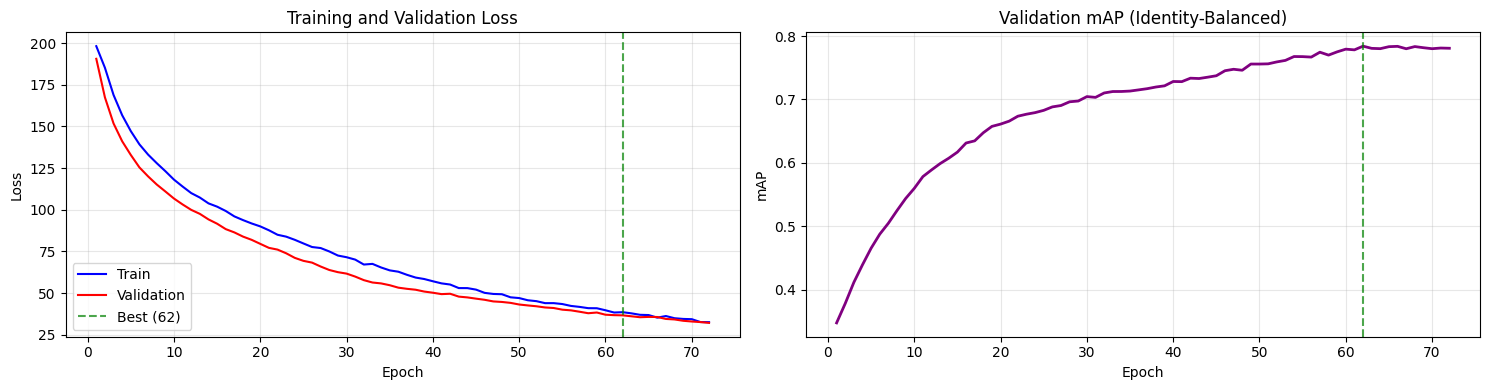

In [112]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sphereface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sphereface": wandb.Image(fig)})

In [58]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_sphereface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 0.0000
  Val mAP: 0.3418


In [59]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


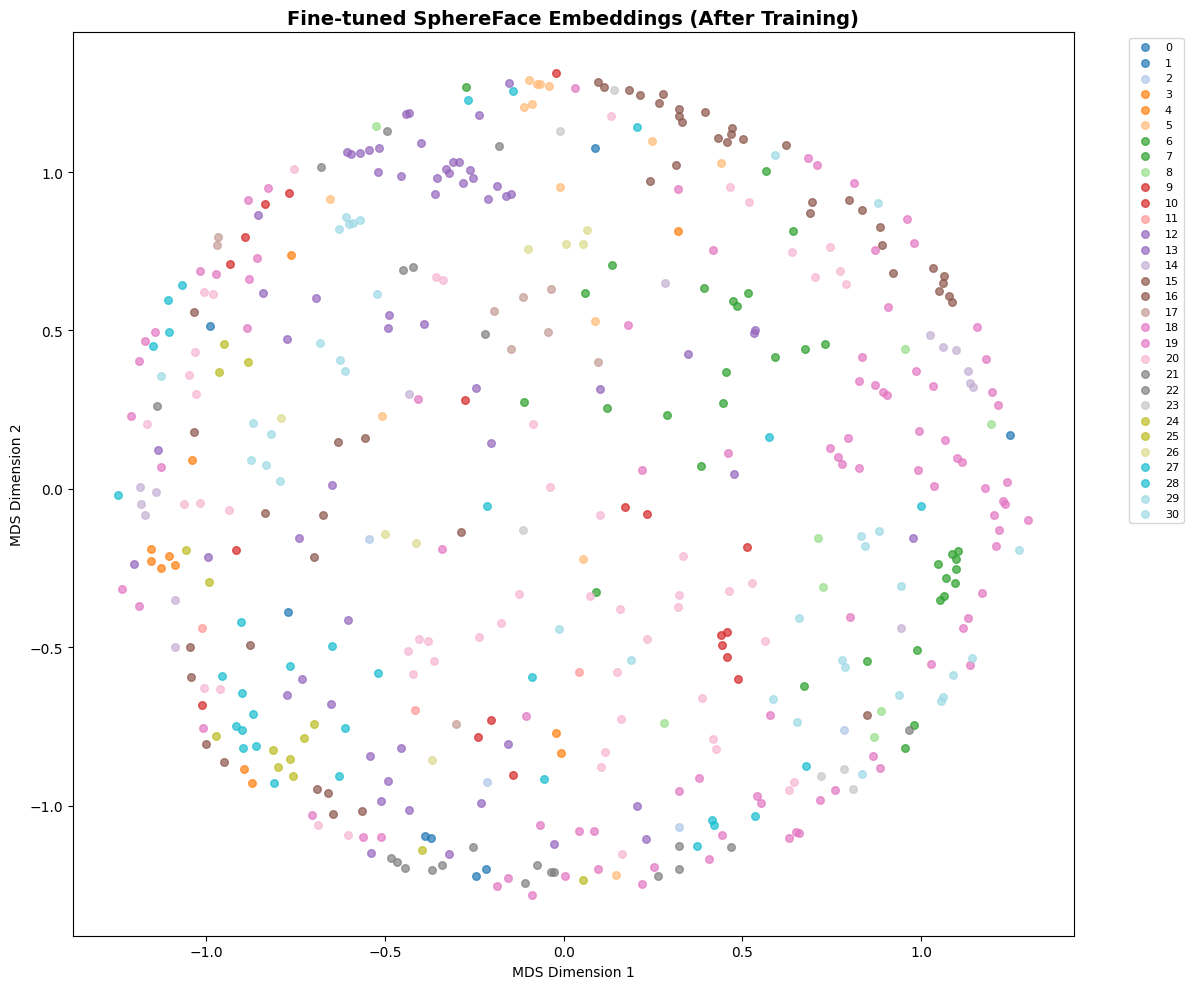

In [60]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SphereFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sphereface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sphereface": wandb.Image(fig_finetuned)})

In [61]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Proxy Anchor Loss

In [62]:
class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, margin=0.1, alpha=32):
        super().__init__()
        self.proxies = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.kaiming_normal_(self.proxies, mode='fan_out')
        self.margin = margin
        self.alpha = alpha

    def forward(self, features, labels):
        features = F.normalize(features)
        proxies = F.normalize(self.proxies)

        sim = F.linear(features, proxies)  # cosine similarity

        pos_mask = F.one_hot(labels, num_classes=sim.size(1)).bool()
        neg_mask = ~pos_mask

        pos_exp = torch.exp(-self.alpha * (sim - self.margin)) * pos_mask
        neg_exp = torch.exp(self.alpha * (sim + self.margin)) * neg_mask

        pos_term = torch.log(1 + pos_exp.sum(dim=0)).sum()
        neg_term = torch.log(1 + neg_exp.sum(dim=0)).sum()

        loss = (pos_term + neg_term) / features.size(0)
        return loss
    
print(f"ProxyAnchor Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")

ProxyAnchor Model:
  Embedding dim: 256
  Num classes: 31
  ProxyAnchor margin: 0.1
  ProxyAnchor alpha: 32.0


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ProxyAnchorLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    margin=config["proxyanchor_margin"], 
    alpha=config["proxyanchor_alpha"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [66]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="proxyanchor"
)

wandb.log({
    "final_val_mAP_proxyanchor": best_map,
    "best_epoch_proxyanchor": best_epoch,
    "total_epochs_proxyanchor": len(history['train_loss']),
})

table.append([
    "ProxyAnchor",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s, loss=10.2044]

  Train Loss: 9.8001
  Val Loss:   8.0024
  Val mAP:    0.3402 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 8.9559
  Val Loss:   7.7113
  Val mAP:    0.3458 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.5269
  Val Loss:   7.5227
  Val mAP:    0.3480 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 2.4443
  Val Loss:   2.3140
  Val mAP:    0.7302 | LR: 6.25e-06
  No improvement. Patience: 6/10

Epoch 176/200


  Train Loss: 2.4579
  Val Loss:   2.3346
  Val mAP:    0.7307 | LR: 6.25e-06
  No improvement. Patience: 7/10

Epoch 177/200


  Train Loss: 2.4287
  Val Loss:   2.3347
  Val mAP:    0.7328 | LR: 6.25e-06
  No improvement. Patience: 8/10

Epoch 178/200


  Train Loss: 2.4853
  Val Loss:   2.3527
  Val mAP:    0.7338 | LR: 6.25e-06
  No improvement. Patience: 9/10

Epoch 179/200


  Train Loss: 2.5016
  Val Loss:   2.4336
  Val mAP:    0.7352 | LR: 6.25e-06
  No improvement. Patience: 10/10

Early stopping triggered after 179 epochs

Training complete!
Best epoch: 169, Val mAP: 0.7409


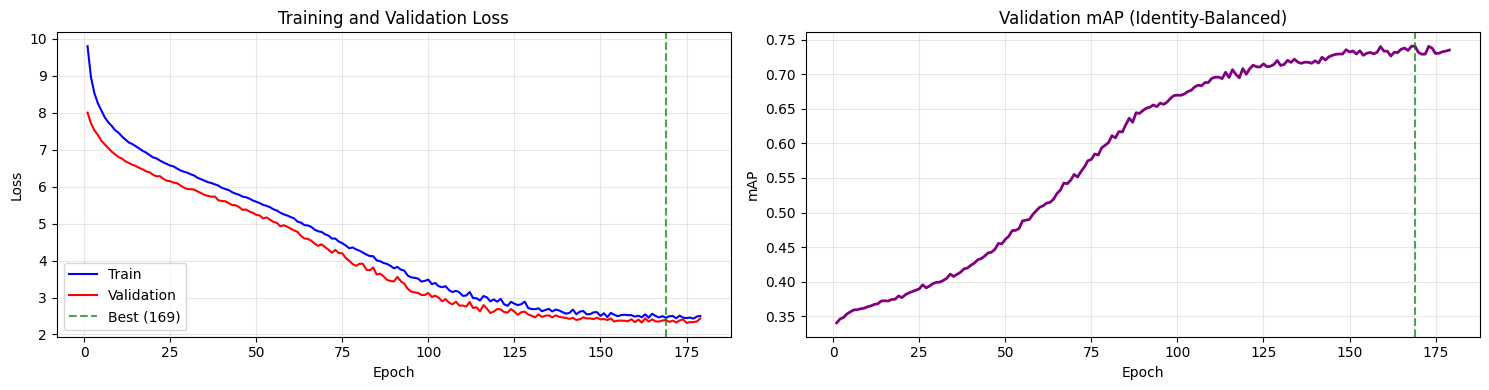

In [67]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor": wandb.Image(fig)})

In [68]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_proxyanchor.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 2.3899
  Val mAP: 0.7409


In [69]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


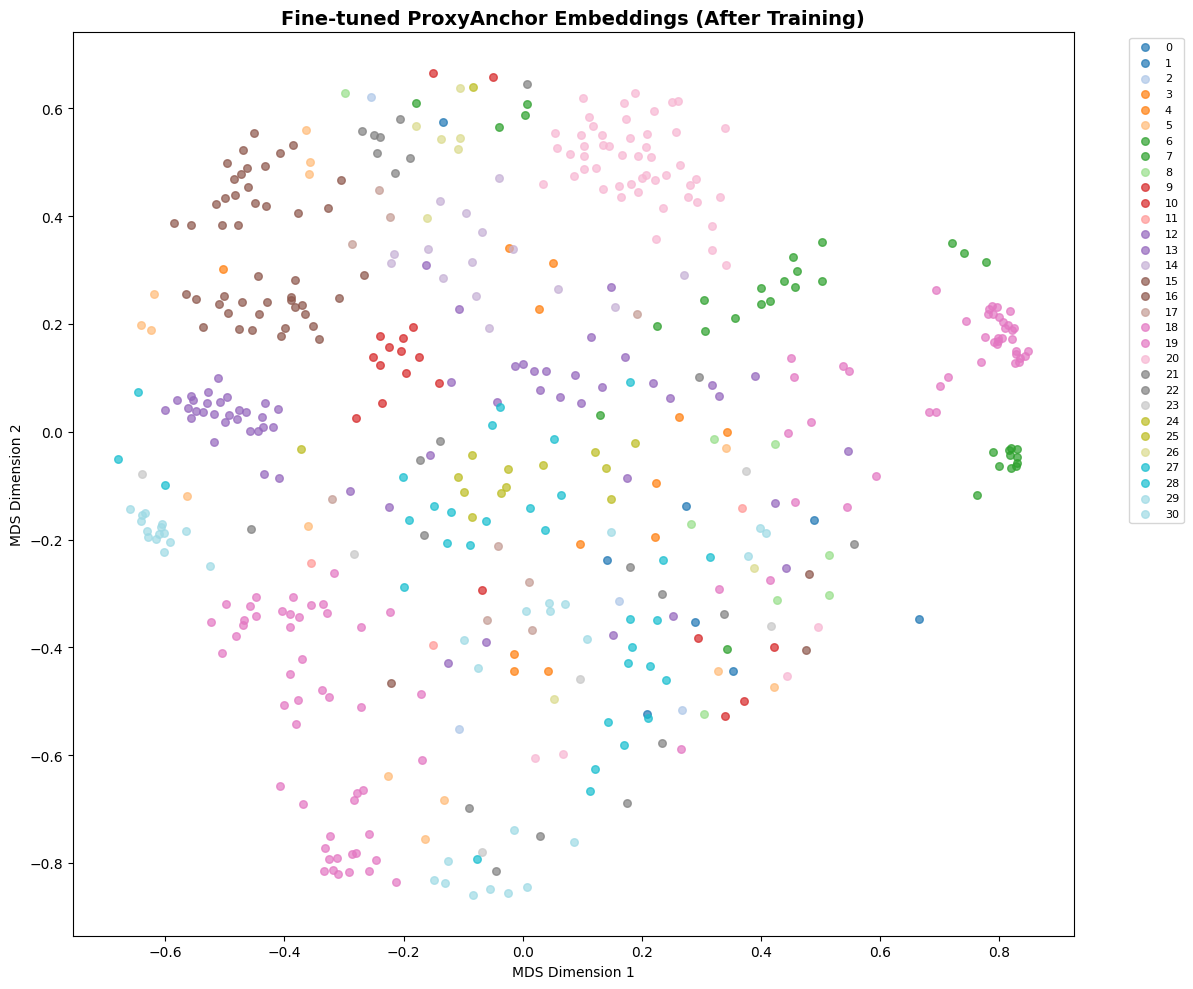

In [70]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor": wandb.Image(fig_finetuned)})

In [71]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Sub-Center ArcFace

In [74]:
class SubCenterArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_dim, k=3, scale=30.0, margin=0.50):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.k = k
        self.num_classes = num_classes

        self.weight = nn.Parameter(
            torch.randn(num_classes * k, embedding_dim)
        )
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features, labels):
        features = F.normalize(features)
        weight = F.normalize(self.weight)

        cosine = F.linear(features, weight)
        cosine = cosine.view(-1, self.num_classes, self.k)

        cosine, _ = cosine.max(dim=2)  # pick closest sub-center

        theta = torch.acos(torch.clamp(cosine, -1 + 1e-7, 1 - 1e-7))
        target_cosine = torch.cos(theta + self.margin)

        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()

        logits = cosine * (1 - one_hot) + target_cosine * one_hot
        logits *= self.scale
        loss = F.cross_entropy(logits, labels)
    
        return loss


print(f"SubCenterArcFace Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SubCenterArcFace k: {config['subcenter_arcface_num_subcenters']}")
print(f"  SubCenterArcFace margin: {config['subcenter_arcface_margin']}")
print(f"  SubCenterArcFace scale: {config['subcenter_arcface_scale']}")

SubCenterArcFace Model:
  Embedding dim: 256
  Num classes: 31
  SubCenterArcFace k: 3
  SubCenterArcFace margin: 0.5
  SubCenterArcFace scale: 64.0


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SubCenterArcFaceLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    k=config["subcenter_arcface_num_subcenters"],
    margin=config["subcenter_arcface_margin"],
    scale=config["subcenter_arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: SubCenterArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: SubCenterArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [76]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="subcenterarcface"
)

wandb.log({
    "final_val_mAP_subcenterarcface": best_map,
    "best_epoch_subcenterarcface": best_epoch,
    "total_epochs_subcenterarcface": len(history['train_loss']),
})

table.append([
    "SubCenterArcFace",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 36.2421
  Val Loss:   32.8497
  Val mAP:    0.3418 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.5476
  Val Loss:   28.7075
  Val mAP:    0.3561 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.4460
  Val Loss:   25.2809
  Val mAP:    0.3691 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.4909
  Val Loss:   3.0576
  Val mAP:    0.7213 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 99/200


  Train Loss: 0.4569
  Val Loss:   3.0061
  Val mAP:    0.7278 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 100/200


  Train Loss: 0.4036
  Val Loss:   3.0195
  Val mAP:    0.7269 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 101/200


  Train Loss: 0.3774
  Val Loss:   2.9802
  Val mAP:    0.7288 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 102/200


  Train Loss: 0.3886
  Val Loss:   3.0402
  Val mAP:    0.7258 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 102 epochs

Training complete!
Best epoch: 92, Val mAP: 0.7334


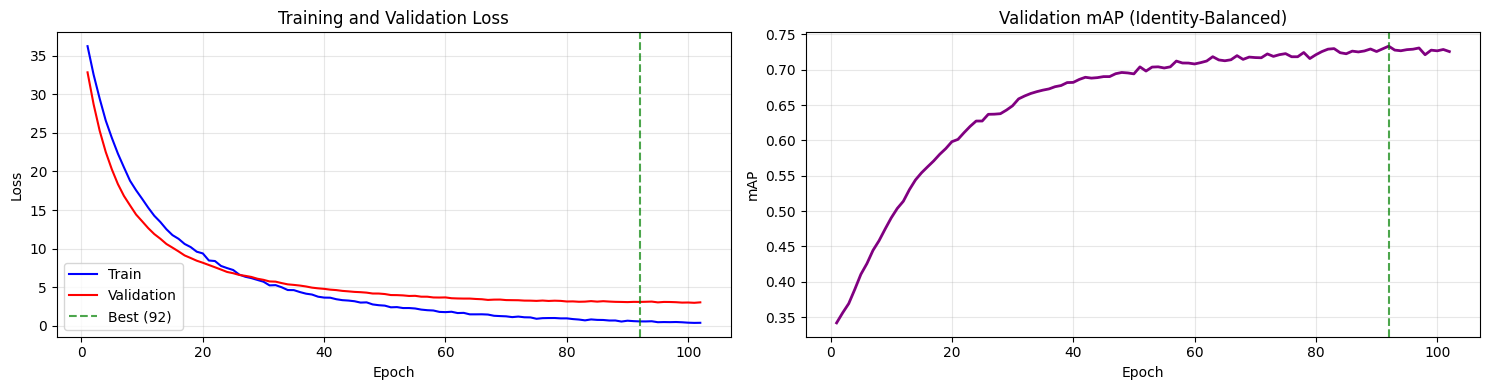

In [80]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sub_center_arc_face.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sub_center_arc_face": wandb.Image(fig)})

In [81]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_subcenterarcface.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 3.0950
  Val mAP: 0.7334


In [82]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


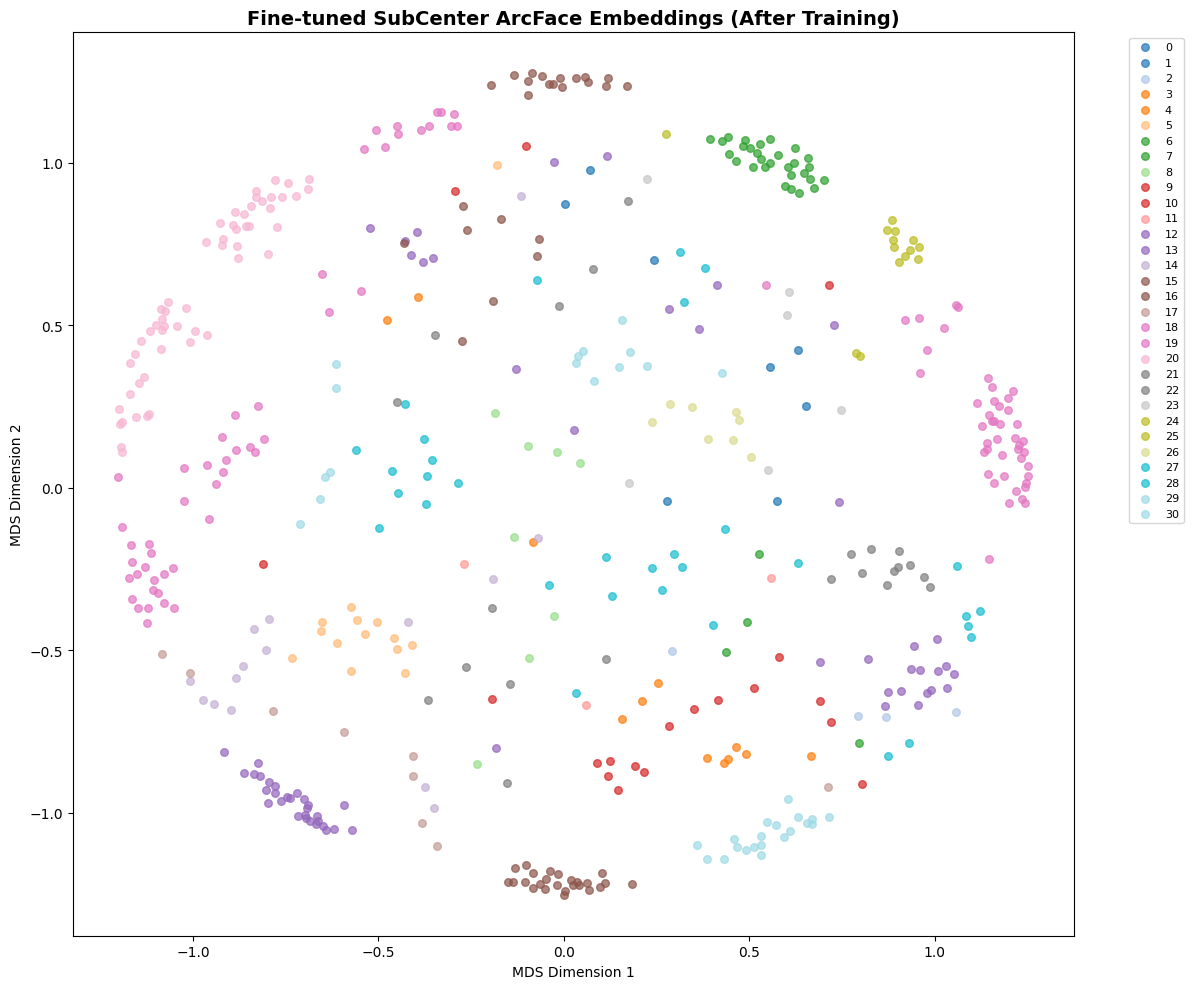

In [83]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SubCenter ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sub_center_arc_face_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sub_center_arc_face": wandb.Image(fig_finetuned)})

In [84]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Center Loss

In [85]:
class CenterLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, embedding_dim))

    def forward(self, features, labels):
        centers_batch = self.centers[labels]
        loss = ((features - centers_batch) ** 2).sum(dim=1).mean()
        return loss

print(f"Center Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")

Center Loss:
  Embedding dim: 256
  Num classes: 31


In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CenterLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: CenterLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: CenterLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [89]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="center_loss"
)

wandb.log({
    "final_val_mAP_center_loss": best_map,
    "best_epoch_center_loss": best_epoch,
    "total_epochs_center_loss": len(history['train_loss']),
})

table.append([
    "Center Loss",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 485.0327
  Val Loss:   365.5720
  Val mAP:    0.3511 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 435.3500
  Val Loss:   332.0822
  Val mAP:    0.3732 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 396.3692
  Val Loss:   301.4444
  Val mAP:    0.3967 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 363.7782
  Val Loss:   277.5120
  Val mAP:    0.4187 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 33.0394
  Val Loss:   36.1603
  Val mAP:    0.8613 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 171/200


  Train Loss: 32.7255
  Val Loss:   35.9094
  Val mAP:    0.8652 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 172/200


  Train Loss: 33.5321
  Val Loss:   36.0400
  Val mAP:    0.8609 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 173/200


  Train Loss: 32.0319
  Val Loss:   36.2407
  Val mAP:    0.8606 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 174/200


  Train Loss: 33.0397
  Val Loss:   35.7901
  Val mAP:    0.8605 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 174 epochs

Training complete!
Best epoch: 164, Val mAP: 0.8656


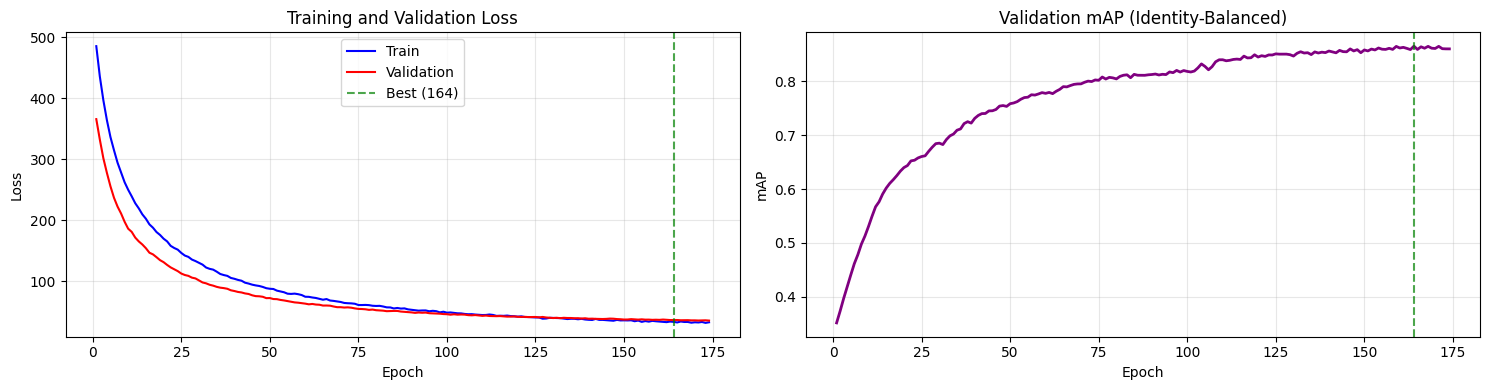

In [90]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_center_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_center_loss": wandb.Image(fig)})

In [91]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_center_loss.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 36.7848
  Val mAP: 0.8656


In [92]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


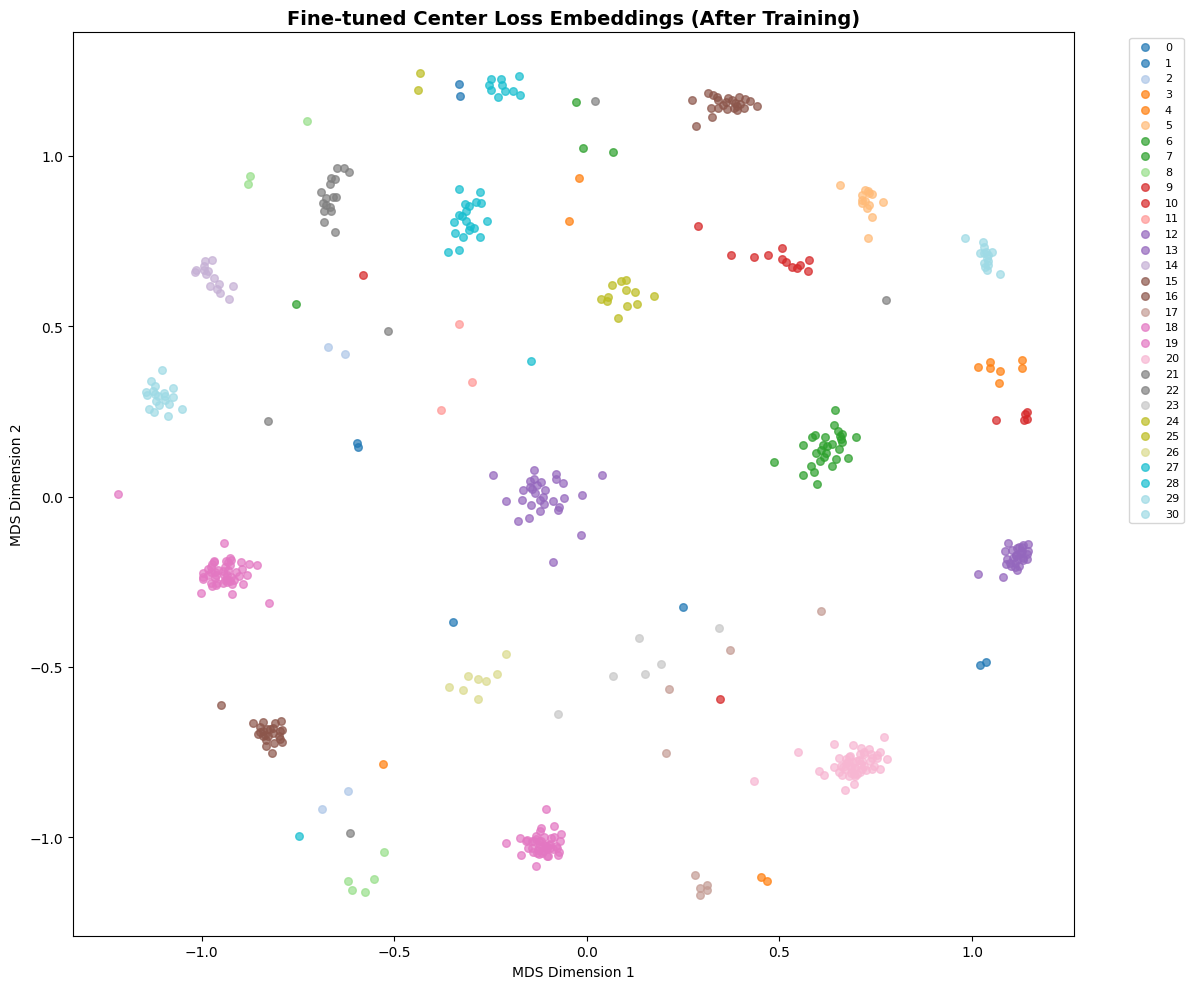

In [93]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Center Loss Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "center_loss_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_center_loss": wandb.Image(fig_finetuned)})

In [94]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Batch-Hard Triplet Loss

In [96]:
class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, features, labels):
        features = F.normalize(features)
        dist = torch.cdist(features, features, p=2)

        labels = labels.unsqueeze(1)
        mask_pos = labels.eq(labels.T)
        mask_neg = ~mask_pos

        hardest_pos = (dist * mask_pos.float()).max(dim=1)[0]

        dist_neg = dist.clone()
        dist_neg[~mask_neg] = float('inf')
        hardest_neg = dist_neg.min(dim=1)[0]

        loss = F.relu(hardest_pos - hardest_neg + self.margin)
        return loss.mean()

print(f"Batch Hard Triplet Loss:")
print(f"  Margin: {config['batch_hard_triplet_margin']}")

Batch Hard Triplet Loss:
  Margin: 0.3


In [97]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = BatchHardTripletLoss(
    margin=config["batch_hard_triplet_margin"]
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,
)

print("Training components initialized:")
print(f"  Loss: BatchHardTripletLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Training components initialized:
  Loss: BatchHardTripletLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [98]:
# Training loop
set_seeds(config['seed'])
history, best_map, best_epoch = train(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="batch_hard_triplet"
)

wandb.log({
    "final_val_mAP_batch_hard_triplet": best_map,
    "best_epoch_batch_hard_triplet": best_epoch,
    "total_epochs_batch_hard_triplet": len(history['train_loss']),
})

table.append([
    "Batch Hard Triplet",
    best_map,
    best_epoch
])

All random seeds set to 51 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 0.2984
  Val Loss:   0.4433
  Val mAP:    0.3746 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 0.2748
  Val Loss:   0.4051
  Val mAP:    0.3988 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 0.2715
  Val Loss:   0.3827
  Val mAP:    0.4263 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 0.2581
  Val Loss:   0.3636
  Val mAP:    0.4473 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.0141
  Val Loss:   0.0654
  Val mAP:    0.7652 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 109/200


  Train Loss: 0.0093
  Val Loss:   0.0671
  Val mAP:    0.7674 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 110/200


  Train Loss: 0.0132
  Val Loss:   0.0660
  Val mAP:    0.7710 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 111/200


  Train Loss: 0.0101
  Val Loss:   0.0651
  Val mAP:    0.7694 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 112/200


  Train Loss: 0.0109
  Val Loss:   0.0647
  Val mAP:    0.7697 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 112 epochs

Training complete!
Best epoch: 102, Val mAP: 0.7717


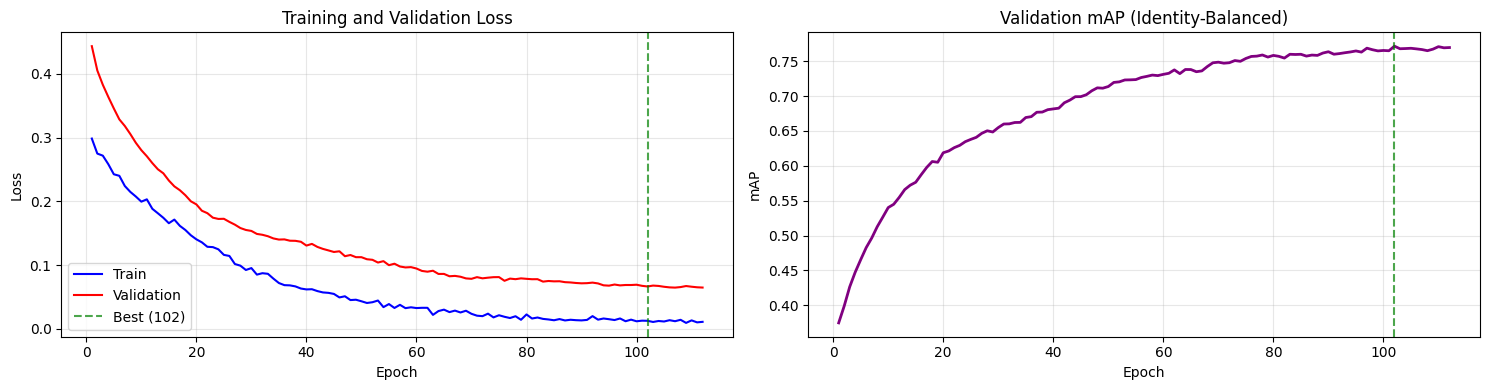

In [99]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_batch_hard_triplet.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_batch_hard_triplet": wandb.Image(fig)})

In [100]:
# Load best model
checkpoint = torch.load(CHECKPOINT_PATH / "model_best_batch_hard_triplet.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {CHECKPOINT_PATH}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss
  Val Loss: 0.0664
  Val mAP: 0.7717


In [101]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


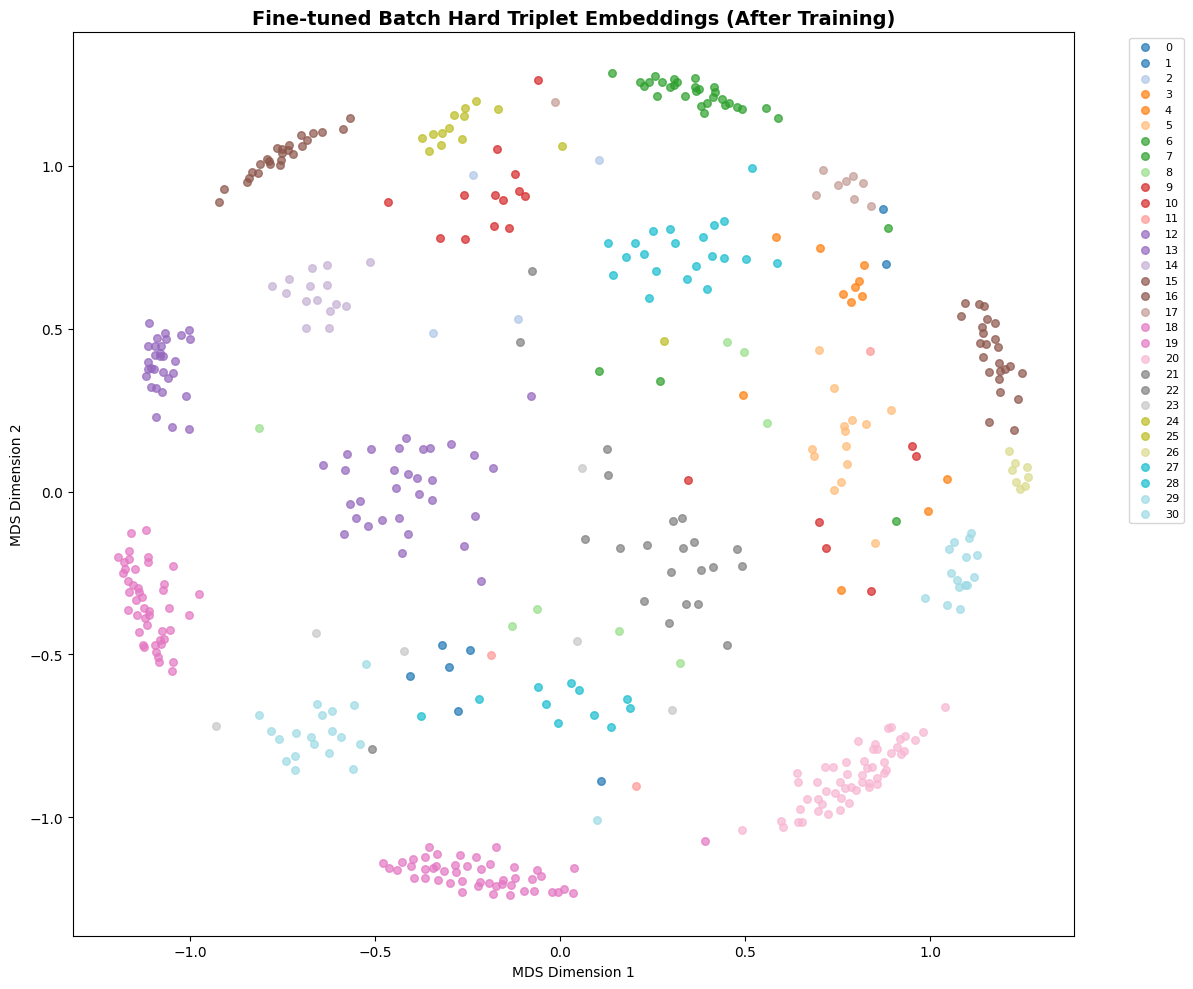

In [102]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Batch Hard Triplet Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "batch_hard_triplet_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_batch_hard_triplet": wandb.Image(fig_finetuned)})

In [103]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [113]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+------------+-----------+--------------+---------------+--------------------+---------------+----------------------+--------------+--------------+
| Loss Function   |    ArcFace |   CosFace |   SphereFace |   ProxyAnchor |   SubCenterArcFace |   Center Loss |   Batch Hard Triplet |   SphereFace |   SphereFace |
+=================+============+===========+==============+===============+====================+===============+======================+==============+==============+
| Best val_mAP    |   0.861588 |  0.849494 |     0.341774 |      0.740879 |           0.733441 |      0.865586 |             0.771715 |     0.341237 |     0.784025 |
+-----------------+------------+-----------+--------------+---------------+--------------------+---------------+----------------------+--------------+--------------+
| Best epoch      | 108        | 95        |    12        |    169        |          92        |    164        |           102        |     5        |    62        |
+---